In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AmesHousing.csv') ##pour guigui
df = pd.read_csv('/AmesHousing (1).csv') ##pour ARMAND
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**STEP 1**

*the available variables and their data types*

In [ ]:
df.columns
df.dtypes

,0
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

The dataset contains 2,930 rows and 82 columns, comprising a mix of variable types. This diversity means that a model cannot be trained on it directly, the categorical variables will need to be encoded later.


 *the distribution of SalePrice*

In [ ]:
df["SalePrice"].describe()

,SalePrice
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


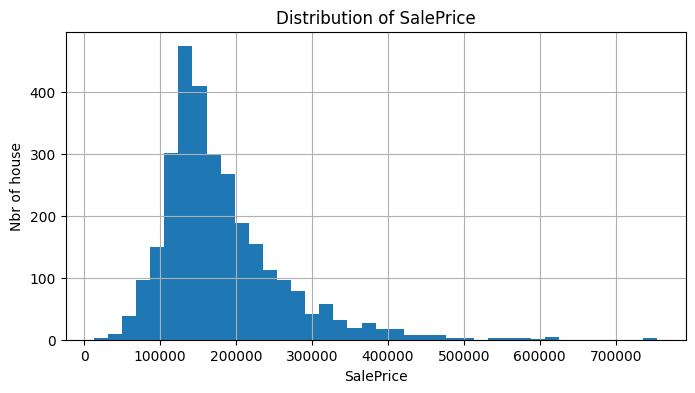

In [ ]:
df["SalePrice"].hist(bins=40, figsize=(8,4))
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Nbr of house")
plt.show()

SalePrice ranges from approximately 1300 to 755000 with a median of 160000 lower than the mean of 181000. The majority of homes sell for between 130000 and 215000 but a long tail of expensive homes skews the distribution.

*Missing* *values*

In [ ]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

,0
Pool QC,2917
Misc Feature,2824
Alley,2732
Fence,2358
Mas Vnr Type,1775
Fireplace Qu,1422
Lot Frontage,490
Garage Qual,159
Garage Cond,159
Garage Yr Blt,159


In [ ]:
(missing / len(df) * 100).round(1)

,0
Pool QC,99.6
Misc Feature,96.4
Alley,93.2
Fence,80.5
Mas Vnr Type,60.6
Fireplace Qu,48.5
Lot Frontage,16.7
Garage Qual,5.4
Garage Cond,5.4
Garage Yr Blt,5.4


In [ ]:
df.loc[df["Garage Type"].isna(), ["Garage Type", "Garage Area", "Garage Cars"]].describe()

,Garage Area,Garage Cars
count,157.0,157.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


27 columns have missing values, ranging from under 1% up to 99.6% for Pool QC. But honestly, it's not actually "missing" data in the broken sense: for Pool QC, Alley, Fence, Fireplace Qu, and the Garage columns, a NaN just means the house doesn't have that feature like no pool, no garage or no basement... Checking Garage Type against Garage Area confirms this exact logic. This completely flips our cleaning strategy. Instead of blindly imputing something like the mean we need to fill those with an explicit category like "None" or 0.

*unusual values or patterns*

In [ ]:
df.sort_values("Gr Liv Area", ascending=False)[["Gr Liv Area", "SalePrice", "Overall Qual", "Sale Condition"]].head(10)

,Gr Liv Area,SalePrice,Overall Qual,Sale Condition
1498,5642,160000,10,Partial
2180,5095,183850,10,Partial
2181,4676,184750,10,Partial
1760,4476,745000,10,Abnorml
1767,4316,755000,10,Normal
1497,3820,284700,5,Normal
2737,3672,415000,6,Normal
2445,3627,625000,10,Normal
2666,3608,475000,10,Normal
2450,3500,584500,9,Normal


3 house really stand out with a living area above 4600 sq ft, but their sale price is surprisingly low given their huge size and an Overall Qual rating of 10. Their Sale Condition is listed as Partial, which points to an atypical transaction like a new build sold before completion. These are classic outliers worth documentingb and we should probably drop them before training our model.

*relationships that may be useful for predicting house prices*

In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].corr()["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


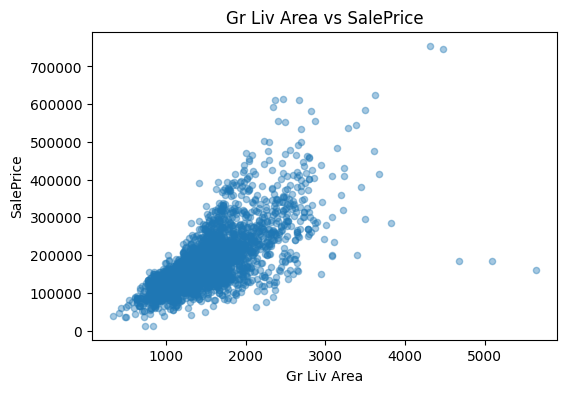

In [ ]:
df.plot.scatter(x="Gr Liv Area", y="SalePrice", alpha=0.4, figsize=(6,4))
plt.title("Gr Liv Area vs SalePrice")
plt.show()

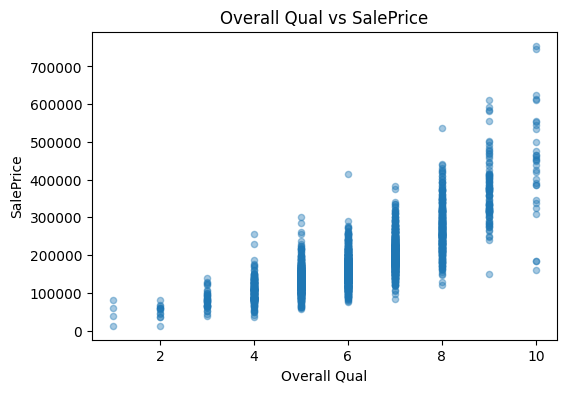

In [ ]:
df.plot.scatter(x="Overall Qual", y="SalePrice", alpha=0.4, figsize=(6,4))
plt.title("Overall Qual vs SalePrice")
plt.show()

Overall Qual and Gr Liv Area stand out as the numeric variables most strongly correlated with price, followed by Garage Cars/Garage Area, Total Bsmt SF, and Year Built. The scatter plot confirms a clear trend between Overall Qual and SalePrice: as the overall quality rating goes up, the median price bumps up right along with it.

**STEP 2**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2344, 81), (586, 81), (2344,), (586,))

I split the dataset into a training set (80%, 2,344 rows) and a test set (20%, 586 rows), setting random_state = 1 for reproducibility. The test set is completely locked away and will only be touched at the very end to evaluate our models. It should never be used to guide any data prep or training decisions, Otherwise, we would run right into data leakage.

**STEP 3**

*removing variables when there is a clear reason to do so*

In [ ]:
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()
X_train_prep = X_train_prep.drop(columns=["Order", "PID"])
X_test_prep = X_test_prep.drop(columns=["Order", "PID"])

*handling missing values based on what they represent in the Understanding the Dataset guide*

In [ ]:
none_cols = ["Pool QC", "Alley", "Fence", "Fireplace Qu", "Garage Type", "Garage Finish",
             "Garage Qual", "Garage Cond", "Bsmt Qual", "Bsmt Cond", "Bsmt Exposure",
             "BsmtFin Type 1", "BsmtFin Type 2", "Mas Vnr Type", "Misc Feature"]

for col in none_cols:
    X_train_prep[col] = X_train_prep[col].fillna("None")
    X_test_prep[col] = X_test_prep[col].fillna("None")

zero_cols = ["Garage Yr Blt", "Mas Vnr Area", "BsmtFin SF 1", "BsmtFin SF 2", "Bsmt Unf SF",
             "Total Bsmt SF", "Bsmt Full Bath", "Bsmt Half Bath", "Garage Cars", "Garage Area"]

for col in zero_cols:
    X_train_prep[col] = X_train_prep[col].fillna(0)
    X_test_prep[col] = X_test_prep[col].fillna(0)


In [ ]:
lot_frontage_median = X_train_prep["Lot Frontage"].median()
X_train_prep["Lot Frontage"] = X_train_prep["Lot Frontage"].fillna(lot_frontage_median)
X_test_prep["Lot Frontage"] = X_test_prep["Lot Frontage"].fillna(lot_frontage_median)

electrical_mode = X_train_prep["Electrical"].mode()[0]
X_train_prep["Electrical"] = X_train_prep["Electrical"].fillna(electrical_mode)
X_test_prep["Electrical"] = X_test_prep["Electrical"].fillna(electrical_mode)

In [ ]:
X_train_prep.isna().sum().sum(), X_test_prep.isna().sum().sum()

(np.int64(0), np.int64(0))

*encoding categorical variables*

In [ ]:
cat_cols = X_train_prep.select_dtypes(include="object").columns
cat_cols

Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

In [ ]:
X_train_prep = pd.get_dummies(X_train_prep, columns=cat_cols)
X_test_prep = pd.get_dummies(X_test_prep, columns=cat_cols)

X_train_prep, X_test_prep = X_train_prep.align(X_test_prep, join="left", axis=1, fill_value=0)

*scaling or transforming numerical variables where appropriate*

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_prep[X_train.select_dtypes(include=["int64","float64"]).columns.drop(["Order","PID"], errors="ignore")] = \
    scaler.fit_transform(X_train_prep[X_train.select_dtypes(include=["int64","float64"]).columns.drop(["Order","PID"], errors="ignore")])

This cell converts all categorical (text) columns into numeric 0/1 columns using one-hot encoding, then aligns the train and test sets so they have exactly the same columns.

In [ ]:
X_test_prep[X_test.select_dtypes(include=["int64","float64"]).columns.drop(["Order","PID"], errors="ignore")] = \
    scaler.transform(X_test_prep[X_test.select_dtypes(include=["int64","float64"]).columns.drop(["Order","PID"], errors="ignore")])

This cell standardizes the numerical columns (mean 0, standard deviation 1) so that no variable dominates the model just because of its scale, fitting only on the training data.

In [ ]:
X_train_prep.describe().T[["mean","std"]].head(10)

,mean,std
MS SubClass,-3.182892e-17,1.000213
Lot Frontage,-2.841868e-16,1.000213
Lot Area,-1.076121e-16,1.000213
Overall Qual,2.334121e-16,1.000213
Overall Cond,-9.851808e-18,1.000213
Year Built,-6.562820e-16,1.000213
Year Remod/Add,-4.986531e-16,1.000213
Mas Vnr Area,-2.349277e-17,1.000213
BsmtFin SF 1,-3.486025e-17,1.000213
BsmtFin SF 2,-3.220784e-17,1.000213


**STEP 4**

This cell checks how many columns exist after one-hot encoding, compared to the original number of features.

In [ ]:
X_train_prep.shape

(2344, 318)

This cell recalculates correlations with SalePrice, now including the encoded categorical columns.

In [ ]:
train_full = X_train_prep.copy()
train_full["SalePrice"] = y_train

correlations = train_full.corr()["SalePrice"].sort_values(ascending=False)
correlations.head(15)

,SalePrice
SalePrice,1.000000
Overall Qual,0.796835
Gr Liv Area,0.694907
Garage Cars,0.641458
Garage Area,0.635002
Total Bsmt SF,0.626079
1st Flr SF,0.617046
Bsmt Qual_Ex,0.586966
Year Built,0.558565
Full Bath,0.546340


This cell shows the most negatively correlated features with SalePrice.

In [ ]:
correlations.tail(10)


,SalePrice
Lot Shape_Reg,-0.298310
Heating QC_TA,-0.332796
Foundation_CBlock,-0.342674
Garage Type_Detchd,-0.371283
Mas Vnr Type_None,-0.397993
Garage Finish_Unf,-0.416908
Bsmt Qual_TA,-0.444401
Fireplace Qu_None,-0.485573
Kitchen Qual_TA,-0.525192
Exter Qual_TA,-0.583226


This cell shows the most positively correlated features with SalePrice.

In [ ]:
correlations.head(15)

,SalePrice
SalePrice,1.000000
Overall Qual,0.796835
Gr Liv Area,0.694907
Garage Cars,0.641458
Garage Area,0.635002
Total Bsmt SF,0.626079
1st Flr SF,0.617046
Bsmt Qual_Ex,0.586966
Year Built,0.558565
Full Bath,0.546340


This cell finds where Order and PID rank in the correlation list, to confirm they carry no real signal.

In [ ]:
df[["Order", "PID", "SalePrice"]].corr()["SalePrice"][["Order", "PID"]]

,SalePrice
Order,-0.031408
PID,-0.246521


This cell checks whether Order and PID are still present anywhere in the prepared training data.

In [ ]:
[col for col in X_train_prep.columns if "Order" in col or "PID" in col]

[]

This cell checks how strongly Garage Cars and Garage Area are correlated with each other, not just with SalePrice.

In [ ]:
df[["Garage Cars", "Garage Area"]].corr()

,Garage Cars,Garage Area
Garage Cars,1.000000,0.889676
Garage Area,0.889676,1.000000


This cell creates a new feature "house age at sale" by subtracting the year built from the year sold, which is often more informative than the raw year.

In [ ]:
X_train_prep["House Age"] = df.loc[X_train.index, "Yr Sold"] - df.loc[X_train.index, "Year Built"]
X_test_prep["House Age"] = df.loc[X_test.index, "Yr Sold"] - df.loc[X_test.index, "Year Built"]

X_train_prep[["House Age"]].describe()

,House Age
count,2344.000000
mean,35.953072
std,30.463645
min,-1.000000
25%,7.000000
50%,34.000000
75%,54.000000
max,136.000000


This cell checks how many rows have a negative House Age, to confirm it's a small data quirk rather than a widespread issue.

In [ ]:
(X_train_prep["House Age"] < 0).sum()

np.int64(1)

This cell fixes the negative values by treating "sold in the same year it was built" as an age of 0.

In [ ]:
X_train_prep["House Age"] = X_train_prep["House Age"].clip(lower=0)
X_test_prep["House Age"] = X_test_prep["House Age"].clip(lower=0)

This cell checks the correlation between the new House Age feature and SalePrice, to confirm it carries useful information.

In [ ]:
X_train_prep[["House Age"]].corrwith(y_train)

,0
House Age,-0.55884


This cell is a Markdown summary of the feature selection and engineering decisions made in this step.

### Step 4 summary — feature selection and engineering

- **Removed `Order` and `PID`**: these are row/parcel identifiers, not real predictive
  variables. `PID` showed a moderate correlation with SalePrice (-0.25), but this is
  coincidental (linked to how identifiers were assigned by area), not a meaningful
  relationship, so both columns were dropped.
- **Kept `Garage Cars` and `Garage Area`** despite their high correlation with each
  other (0.89): both measure garage size, but we chose to keep both rather than
  remove one, since tree-based models (Decision Tree, Random Forest) handle
  correlated features without issue.
- **Created a new feature, `House Age`** (`Yr Sold - Year Built`), which is more
  informative than the raw construction year alone. One row had a negative value
  (sold the same year it was built, likely a recording quirk), which was corrected
  to 0 using `.clip(lower=0)`. The new feature shows a correlation of -0.56 with
  SalePrice, confirming it carries useful, independent information.

STEP 5

This cell imports the three required models.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

This cell trains all three models on the same prepared training data.

In [ ]:
lin_reg = LinearRegression().fit(X_train_prep, y_train)
tree_reg = DecisionTreeRegressor(random_state=42).fit(X_train_prep, y_train)
forest_reg = RandomForestRegressor(random_state=42).fit(X_train_prep, y_train)

STEP 6

This cell imports the metrics needed to evaluate the models.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

This cell generates predictions on the test set for all three models.

In [ ]:
y_pred_lin = lin_reg.predict(X_test_prep)
y_pred_tree = tree_reg.predict(X_test_prep)
y_pred_forest = forest_reg.predict(X_test_prep)

This cell computes RMSE and R² for each model and puts the results in a comparison table.

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [
        mean_squared_error(y_test, y_pred_lin) ** 0.5,
        mean_squared_error(y_test, y_pred_tree) ** 0.5,
        mean_squared_error(y_test, y_pred_forest) ** 0.5,
    ],
    "R2": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_forest),
    ]
})
results

,Model,RMSE,R2
0,Linear Regression,21252.360660,0.927174
1,Decision Tree,33658.490719,0.817332
2,Random Forest,23112.045084,0.913871


this cell creates a simple bar comparison of RMSE across the three models, to visually support the table in the written answer.

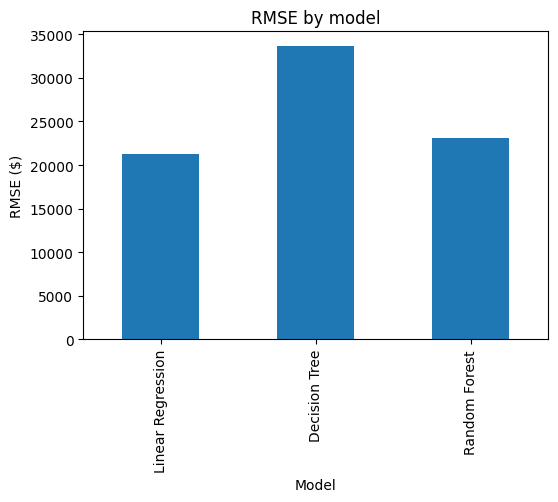

In [ ]:
results.set_index("Model")["RMSE"].plot.bar(figsize=(6,4), title="RMSE by model")
plt.ylabel("RMSE ($)")
plt.show()

Step 6 summary — model evaluation

All three models were evaluated on the held-out test set (never seen during training
or preprocessing), using RMSE and R²:

| Model              | RMSE (\$)  | R²     |
|---------------------|-----------|--------|
| Linear Regression    | 21,252    | 0.927  |
| Decision Tree        | 33,658    | 0.817  |
| Random Forest        | 23,112    | 0.914  |

**Linear Regression performed best** on this test set, both in terms of RMSE (lowest
prediction error) and R² (highest proportion of variance explained), closely followed
by Random Forest. The single Decision Tree performed noticeably worse than both,
likely because an unpruned tree tends to overfit the training data and generalizes
less well to unseen data — an ensemble method like Random Forest reduces this issue
by averaging many trees.

The strong performance of Linear Regression suggests that, after preprocessing
(encoding, scaling) and feature engineering, the relationship between our features
and SalePrice is largely linear.